# Recovering the Parameters of the Curve

We are given only the `x` and `y` coordinates of points from a curve.  
The hidden parameter `t` is not given, and the rows in the CSV are not guaranteed to be sorted.

The curve is:

$$
x(t)=t\cos\theta-e^{M|t|}\sin(0.3t)\sin\theta+X
$$

$$
y(t)=42+t\sin\theta+e^{M|t|}\sin(0.3t)\cos\theta
$$

The goal is to estimate:

- $\theta$
- $M$
- $X$

I will first understand the data visually, then use the structure of the equation to fit the parameters.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares

Y_OFFSET = 42
OMEGA = 0.3
T_MIN, T_MAX = 6, 60
#[theta, M, X] limits 
lower_bounds = [0, -0.05, 0] #theta visually looks in first quadrant , M is varies small since even a small change makes e^M|t| large
upper_bounds = [90, 0.05, 100]

## 1. Load the data

The file contains only two columns: `x` and `y`.  
There is no `t` column, so we cannot directly fit the original equation using known values of `t`.

In [2]:
df = pd.read_csv(r"C:\Users\yashs\Downloads\xy_data.csv")

print(df.shape)
df.head()

(1500, 2)


,x,y
0,88.364456,57.784378
1,74.283936,54.406780
2,60.256474,46.311462
3,82.134370,57.717567
4,101.036390,67.849340


In [3]:
df.describe()

,x,y
count,1500.000000,1500.000000
mean,83.713931,58.263519
std,13.697157,7.696524
min,59.657204,46.032295
25%,72.282910,51.124211
50%,84.710995,57.681288
75%,93.368257,66.138374
max,109.231520,69.685510


In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

x = df["x"].to_numpy(float)
y = df["y"].to_numpy(float)

Missing values:
x    0
y    0
dtype: int64

Duplicate rows: 0


## 2. Plot the points

First I plot the points as a normal scatter plot.  
Then I connect the points in the same order as they appear in the CSV.

If the connected plot looks smooth, then the rows may be sorted by `t`.  
If it looks messy, then the rows are shuffled.

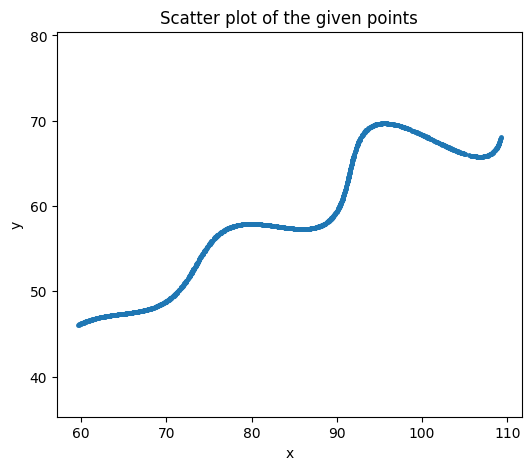

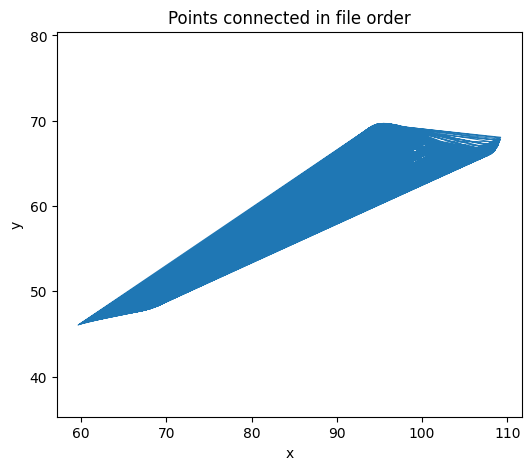

In [5]:
plt.figure(figsize=(6, 5))
plt.scatter(x, y, s=6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter plot of the given points")
plt.axis("equal")
plt.show()

plt.figure(figsize=(6, 5))
plt.plot(x, y, linewidth=0.7)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Points connected in file order")
plt.axis("equal")
plt.show()

## Observation

The scatter plot forms one clear curve.

But when the points are connected in file order, the line becomes messy.  
So the rows are not sorted according to `t`.

That means I should not assume:

```python
t = np.linspace(6, 60, 1500)
```

The method should work even when the points are unordered.

## 3. Main idea

The equation looks complicated because it has hidden unkowns in the the form of t one for every point ie. almost 1500 unkowns.To eliminate this core problem i found an interesting structure in the problem which can help me reduce the number of unkowns.

Let:

$$
u=t
$$

and

$$
v=e^{M|t|}\sin(0.3t)
$$

Then the equation becomes a rotation and translation:

$$
x-X=u\cos\theta-v\sin\theta
$$

$$
y-42=u\sin\theta+v\cos\theta
$$

So the curve is basically a wavy curve in the `(u, v)` plane, rotated by angle $\theta$ and shifted by `(X, 42)`.

So maybe can use PCA to estimate that main direction and get a starting value for $\theta$.

## 4. Estimate the first angle using PCA

PCA gives the main direction of the point cloud.  
The first principal component should point almost along the rotated `t` direction.

In [6]:
points = np.column_stack([x, y])
center = points.mean(axis=0)
points_centered = points - center

cov = np.cov(points_centered.T)

eig_values, eig_vectors = np.linalg.eigh(cov)

order = np.argsort(eig_values)[::-1]
eig_values = eig_values[order]
eig_vectors = eig_vectors[:, order]

explained_ratio = eig_values / eig_values.sum()

print("Eigenvalues:", eig_values)
print("Explained variance ratio:", explained_ratio)
print("Standard deviation along PCs:", np.sqrt(eig_values))

Eigenvalues: [241.17149095   5.67709841]
Explained variance ratio: [0.9770017 0.0229983]
Standard deviation along PCs: [15.52969707  2.38266624]


In [7]:
main_vec = eig_vectors[:, 0]

theta_start = np.degrees(np.arctan2(main_vec[1], main_vec[0]))

if theta_start < 0:
    theta_start += 180
    
print("Initial theta from PCA:", theta_start)

Initial theta from PCA: 28.48314415538411


## 5. Check PCA visually

This plot shows the data with the main PCA direction.  
If the orange line follows the long direction of the curve, then the PCA angle is a good starting point.

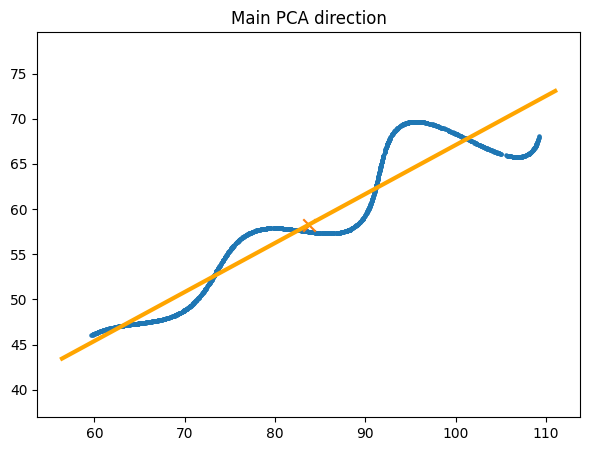

PC1 variance percentage: 97.70016979862916


In [8]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=5)

scale = 2 * np.sqrt(eig_values[0])
vx, vy = main_vec

plt.plot(
    [center[0] - scale * vx, center[0] + scale * vx],
    [center[1] - scale * vy, center[1] + scale * vy],
      color="orange",
    linewidth=3
)

plt.scatter(center[0], center[1], marker="x", s=80)
plt.title("Main PCA direction")
plt.axis("equal")
plt.show()

print("PC1 variance percentage:", explained_ratio[0] * 100)

## Observation

The first principal component explains almost all the variance.  
So the curve is mostly stretched in one direction.

This makes the PCA angle a reasonable first guess for $	theta$.

## 6. Initial guesses for `M` and `X`

For `M`, I start with 0 because we do not know the exponential growth/decay yet.

For `X`, I use the mean of the data.

Since the average value of `t` between 6 and 60 is approximately:

$$
\frac{6+60}{2}=33
$$

and the sine part roughly averages out(assumption), we can use:

$$
\bar{x}\approx X+33\cos(\theta)
$$

So:

$$
X\approx \bar{x}-33\cos(\theta)
$$

In [9]:
theta_rad = np.radians(theta_start)

M_start = 0
X_start = x.mean() - 33 * np.cos(theta_rad)

X_start = np.clip(X_start, 0.001, 99.999)

start = np.array([theta_start, M_start, X_start])

print("Initial guess:")
print("theta =", start[0])
print("M     =", start[1])
print("X     =", start[2])

Initial guess:
theta = 28.48314415538411
M     = 0.0
X     = 54.70833560733719


## 7. Convert each point back to estimated `t`

For any guessed values of $\theta$ and `X`, we can undo the rotation:

$$
\hat{t}=(x-X)\cos\theta+(y-42)\sin\theta
$$

$$
\hat{v}=-(x-X)\sin\theta+(y-42)\cos\theta
$$

At the correct parameters:

$$
\hat{v}=e^{M|\hat{t}|}\sin(0.3\hat{t})
$$

So I fit the parameters by making the difference between these two values as small as possible.

In [10]:
def residual(params, x, y):
    theta_deg, M, X = params

    theta = np.radians(theta_deg)
    c = np.cos(theta)
    s = np.sin(theta)

    t_hat = (x - X) * c + (y - Y_OFFSET) * s
    v_hat = -(x - X) * s + (y - Y_OFFSET) * c

    v_model = np.exp(M * np.abs(t_hat)) * np.sin(OMEGA * t_hat)

    return v_hat - v_model


def rmse(params, x, y):
    r = residual(params, x, y)
    return np.sqrt(np.mean(r ** 2))

In [11]:
print("Initial RMSE:", rmse(start, x, y))

Initial RMSE: 1.8383756032523362


## 8. Fit the parameters

Now I use nonlinear least squares.  
The PCA-based values are only the starting point.  
The optimizer improves them to minimize the residual.

In [12]:
result = least_squares(
    residual,
    start,
    args=(x, y),
    bounds=(lower_bounds, upper_bounds)
)

theta_fit, M_fit, X_fit = result.x

print("Optimization successful:", result.success)
print(result.message)

print("\nFitted values:")
print("theta =", theta_fit)
print("M     =", M_fit)
print("X     =", X_fit)

print("\nFinal RMSE:", rmse(result.x, x, y))

Optimization successful: True
`gtol` termination condition is satisfied.

Fitted values:
theta = 29.999972932158297
M     = 0.029999996873059674
X     = 54.99999821279947

Final RMSE: 3.4861611513047756e-06


## 9. Compare before and after fitting



In [13]:
initial_error = rmse(start, x, y)
final_error = rmse(result.x, x, y)

print("Initial RMSE:", initial_error)
print("Final RMSE  :", final_error)
print("Improvement :", initial_error / final_error)

Initial RMSE: 1.8383756032523362
Final RMSE  : 3.4861611513047756e-06
Improvement : 527335.2330727115


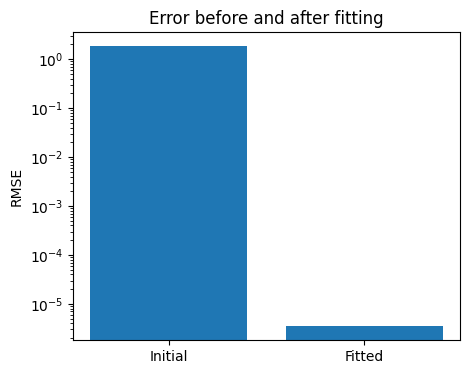

In [14]:
plt.figure(figsize=(5, 4))
plt.bar(["Initial", "Fitted"], [initial_error, final_error])
plt.yscale("log")
plt.ylabel("RMSE")
plt.title("Error before and after fitting")
plt.show()

## 10. Validate recovered `t`

The recovered values of `t` should lie inside the expected interval `(6, 60)`.

In [15]:
theta = np.radians(theta_fit)
c = np.cos(theta)
s = np.sin(theta)

t_hat = (x - X_fit) * c + (y - Y_OFFSET) * s

print("Minimum recovered t:", t_hat.min())
print("Maximum recovered t:", t_hat.max())

Minimum recovered t: 6.049405472718361
Maximum recovered t: 59.99517070234954


## 11. Plot the fitted curve

To check the result visually, I generate a smooth curve using the fitted parameters and compare it with the original points.

In [16]:
def curve(t, theta_deg, M, X):
    theta = np.radians(theta_deg)

    v = np.exp(M * np.abs(t)) * np.sin(OMEGA * t)

    x_curve = t * np.cos(theta) - v * np.sin(theta) + X
    y_curve = Y_OFFSET + t * np.sin(theta) + v * np.cos(theta)

    return x_curve, y_curve

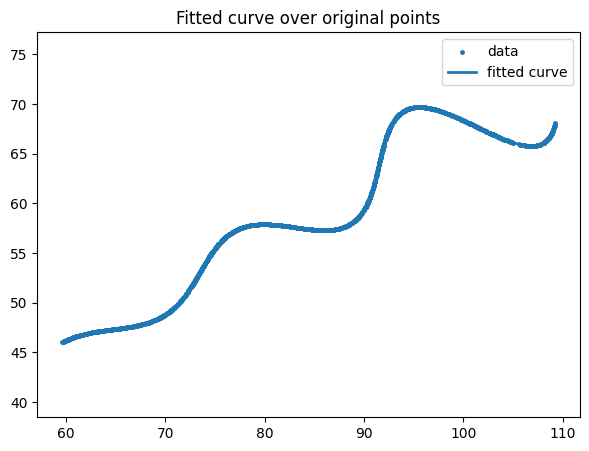

In [17]:
t_smooth = np.linspace(T_MIN, T_MAX, 3000)
x_curve, y_curve = curve(t_smooth, theta_fit, M_fit, X_fit)

plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=6, label="data")
plt.plot(x_curve, y_curve, linewidth=2, label="fitted curve")
plt.legend()
plt.axis("equal")
plt.title("Fitted curve over original points")
plt.show()

## 12. Check point-wise error

I also check how far each original point is from the fitted curve after recovering its `t`.

Mean point error: 2.559805438449734e-06
Max point error : 1.7615054851886206e-05


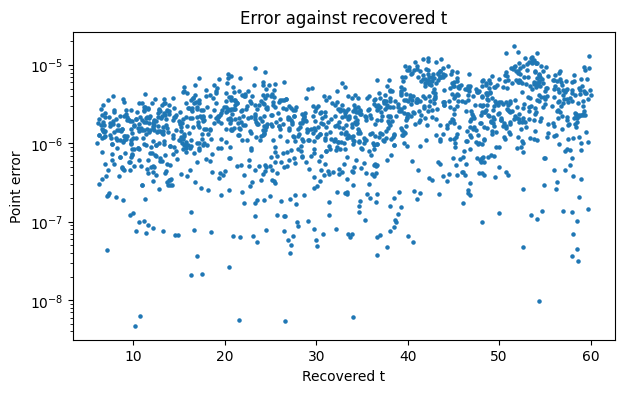

In [18]:
x_pred, y_pred = curve(t_hat, theta_fit, M_fit, X_fit)

point_error = np.sqrt((x_pred - x) ** 2 + (y_pred - y) ** 2)

print("Mean point error:", point_error.mean())
print("Max point error :", point_error.max())

plt.figure(figsize=(7, 4))
plt.scatter(t_hat, point_error, s=5)
plt.yscale("log")
plt.xlabel("Recovered t")
plt.ylabel("Point error")
plt.title("Error against recovered t")
plt.show()

## Check by Optuna

Check by Optuna since the original method was using an initial guess of pca and it can answer local minima so a final check by optuna considering all 1500 different values of t indeed shows that this in not local minima. -(Akiba et al., 2019)


In [19]:
import warnings
import optuna
from scipy.spatial import cKDTree

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.ERROR)

def objective(trial):
    theta = trial.suggest_float("theta", 0, 50)
    M = trial.suggest_float("M", -0.05, 0.05)
    X = trial.suggest_float("X", 0, 100)

    t_dense = np.linspace(T_MIN, T_MAX, 1500)
    x_curve, y_curve = curve(t_dense, theta, M, X)

    curve_points = np.column_stack([x_curve, y_curve])
    data_points = np.column_stack([x, y])

    tree = cKDTree(curve_points)
    distances, _ = tree.query(data_points, k=1)

    return np.mean(distances ** 2)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=300, show_progress_bar=False)

best_params = study.best_params

theta_global = best_params["theta"]
M_global = best_params["M"]
X_global = best_params["X"]
global_loss = study.best_value

print("Best parameters from Optuna:")
print("theta =", theta_global)
print("M     =", M_global)
print("X     =", X_global)
print("Loss  =", global_loss)

Best parameters from Optuna:
theta = 29.26399628138901
M     = 0.03007641913069577
X     = 54.818145898446794
Loss  = 0.11401925598927008


In [20]:
print("Method 1:")
print(theta_fit, M_fit, X_fit)

print("\nMethod 2:")
print(theta_global, M_global, X_global)

Method 1:
29.999972932158297 0.029999996873059674 54.99999821279947

Method 2:
29.26399628138901 0.03007641913069577 54.818145898446794


## 13. Final rounded answer

The fitted values are extremely close to clean numbers.

So the final answer is:

- $	theta = 30^\circ$
- $M = 0.03$
- $X = 55$

In [21]:
theta_clean = 30
M_clean = 0.03
X_clean = 55

print("Clean values:")
print("theta =", theta_clean)
print("M     =", M_clean)
print("X     =", X_clean)

print("\nRMSE using clean values:", rmse([theta_clean, M_clean, X_clean], x, y))

Clean values:
theta = 30
M     = 0.03
X     = 55

RMSE using clean values: 1.7084739230942516e-05


## Final conclusion

The data was unordered, so directly assigning `t` by row number was not safe.

The useful fact was to notice that the given equation is a rotated and shifted version of a simpler curve.(This fact helped me a lot since now i was able to eliminate t and the number of unkowns remain 3 only else we have to predict using 1500 values of t which was tedious task)  

PCA gave a good initial estimate of the rotation angle, and least squares refined all three unknown parameters.

Final check by optuna to see if the method is not lying in local minima.

The recovered parameters are:

$$
    {	theta=30^\circ,\quad M=0.03,\quad X=55}
$$

In [22]:
theta_rad = np.radians(theta_clean)

desmos = (
    rf"\left(t\cos({theta_rad:.6f})"
    rf"-e^{{{M_clean}|t|}}\sin(0.3t)\sin({theta_rad:.6f})+{X_clean},"
    rf"42+t\sin({theta_rad:.6f})"
    rf"+e^{{{M_clean}|t|}}\sin(0.3t)\cos({theta_rad:.6f})\right)"
)

print(desmos)

\left(t\cos(0.523599)-e^{0.03|t|}\sin(0.3t)\sin(0.523599)+55,42+t\sin(0.523599)+e^{0.03|t|}\sin(0.3t)\cos(0.523599)\right)


# Fun Exploration After Results
This portion contains some additional graphical methods to estimate M along with so exciting insights on the data.

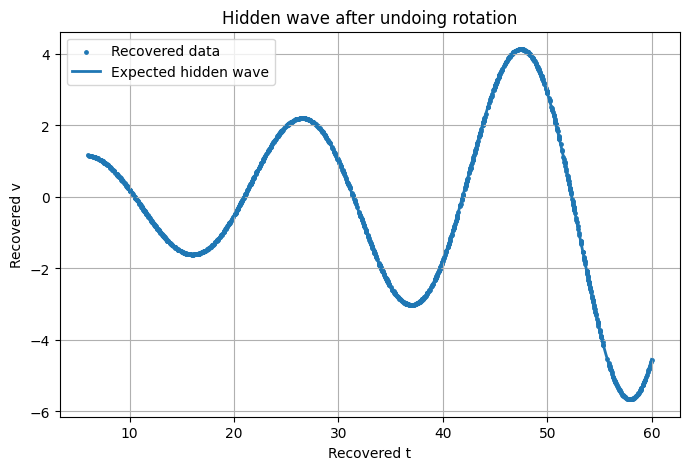

In [23]:
theta = np.radians(theta_fit)
c = np.cos(theta)
s = np.sin(theta)

t_hat = (x - X_fit) * c + (y - Y_OFFSET) * s
v_hat = -(x - X_fit) * s + (y - Y_OFFSET) * c

t_smooth = np.linspace(T_MIN, T_MAX, 2000)
v_smooth = np.exp(M_fit * np.abs(t_smooth)) * np.sin(OMEGA * t_smooth)

plt.figure(figsize=(8, 5))
plt.scatter(t_hat, v_hat, s=6, label="Recovered data")
plt.plot(t_smooth, v_smooth, linewidth=2, label="Expected hidden wave")

plt.xlabel("Recovered t")
plt.ylabel("Recovered v")
plt.title("Hidden wave after undoing rotation")
plt.legend()
plt.grid(True)
plt.show()

If we zoom out and look all this through the graphical method well notice that neither theta nor X does anything to the graph pattern actually they just rotate and shift the graph so we should estimate M first.

## Graphical Method 1: Estimating $M$
In this i used the fact that sin value become 1 at the peak so if take log of the v function it will essentially be a straight line whose slope gives the value of M.

In [24]:
theta = np.radians(theta_fit)
c = np.cos(theta)
s = np.sin(theta)

t_hat = (x - X_fit) * c + (y - Y_OFFSET) * s
v_hat = -(x - X_fit) * s + (y - Y_OFFSET) * c

order = np.argsort(t_hat)
t_sorted = t_hat[order]
v_sorted = v_hat[order]

abs_v = np.abs(v_sorted)

mask = abs_v > np.percentile(abs_v, 70)

t_env = t_sorted[mask]
log_env = np.log(abs_v[mask])

coef = np.polyfit(t_env, log_env, 1)
M_from_envelope = coef[0]

print("M from curve fitting:", M_fit)
print("M from envelope slope:", M_from_envelope)

M from curve fitting: 0.029999996873059674
M from envelope slope: 0.025522443733414082


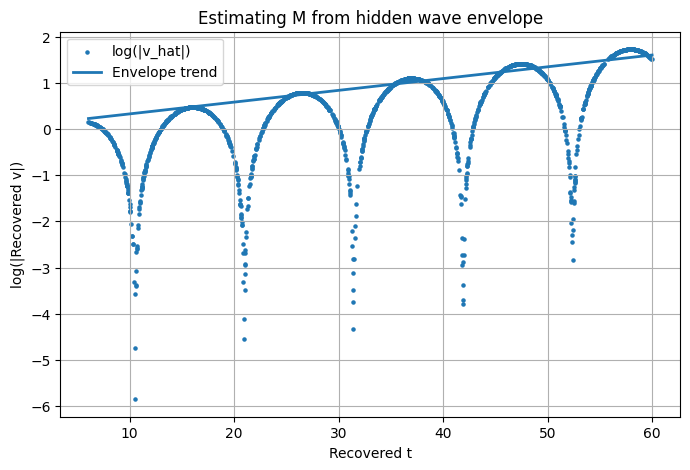

In [25]:
plt.figure(figsize=(8, 5))

plt.scatter(t_sorted, np.log(abs_v + 1e-8), s=5, label="log(|v_hat|)")

line = coef[0] * t_sorted + coef[1]
plt.plot(t_sorted, line, linewidth=2, label="Envelope trend")

plt.xlabel("Recovered t")
plt.ylabel("log(|Recovered v|)")
plt.title("Estimating M from hidden wave envelope")
plt.legend()
plt.grid(True)
plt.show()

## Graphical Method 2: Estimating $M$

In this, I used the fact that the curvature of $v$ depends on the value of $M$:

$$
\kappa(t)=
\frac{|v''(t)|}
{\left(1+(v'(t))^2\right)^{3/2}}.
$$

In [26]:
def curvature_signature(t, v):
    dx = np.gradient(t)
    dy = np.gradient(v)

    ddx = np.gradient(dx)
    ddy = np.gradient(dy)

    k = np.abs(dx * ddy - dy * ddx) / ((dx**2 + dy**2) ** 1.5 + 1e-12)
    return k

In [27]:
theta = np.radians(theta_fit)
c = np.cos(theta)
s = np.sin(theta)

t_hat = (x - X_fit) * c + (y - Y_OFFSET) * s
v_hat = -(x - X_fit) * s + (y - Y_OFFSET) * c

order = np.argsort(t_hat)
t_data = t_hat[order]
v_data = v_hat[order]

k_data = curvature_signature(t_data, v_data)

In [28]:
M_values = np.linspace(0.0, 0.05, 200)
errors = []

for M_try in M_values:
    t_model = np.linspace(T_MIN, T_MAX, len(t_data))
    v_model = np.exp(M_try * np.abs(t_model)) * np.sin(OMEGA * t_model)

    k_model = curvature_signature(t_model, v_model)

    k_model_interp = np.interp(t_data, t_model, k_model)

    error = np.mean((k_data - k_model_interp) ** 2)
    errors.append(error)

errors = np.array(errors)

best_idx = np.argmin(errors)
M_curvature = M_values[best_idx]

print("M from main fitting:", M_fit)
print("M from curvature signature:", M_curvature)

M from main fitting: 0.029999996873059674
M from curvature signature: 0.040703517587939705


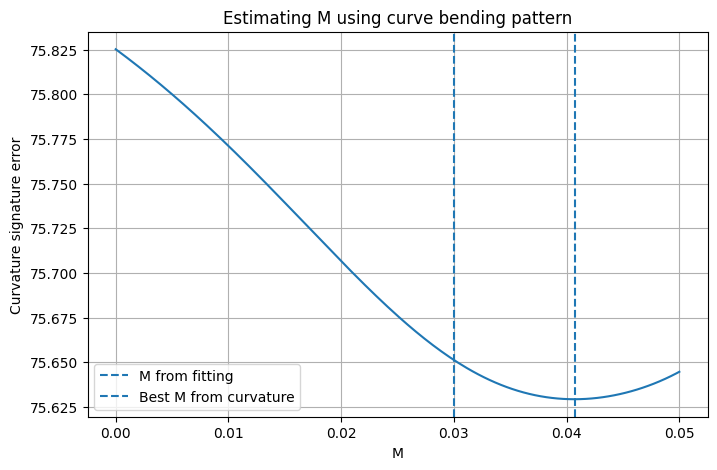

In [29]:
plt.figure(figsize=(8, 5))
plt.plot(M_values, errors)
plt.axvline(M_fit, linestyle="--", label="M from fitting")
plt.axvline(M_curvature, linestyle="--", label="Best M from curvature")

plt.xlabel("M")
plt.ylabel("Curvature signature error")
plt.title("Estimating M using curve bending pattern")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

theta = np.radians(theta_fit)

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter([], [], s=8)
line, = ax.plot([], [], linewidth=2)

ax.set_title("Undoing rotation to reveal the hidden wave")
ax.set_xlabel("Transformed x")
ax.set_ylabel("Transformed y")
ax.grid(True)

frames = 80

all_x = []
all_y = []

for i in range(frames):
    a = i / (frames - 1)
    
    angle = -a * theta
    c = np.cos(angle)
    s = np.sin(angle)
    
    x_shift = x - a * X_fit
    y_shift = y - a * Y_OFFSET
    
    x_new = x_shift * c - y_shift * s
    y_new = x_shift * s + y_shift * c
    
    all_x.extend(x_new)
    all_y.extend(y_new)

ax.set_xlim(min(all_x), max(all_x))
ax.set_ylim(min(all_y), max(all_y))

def update(i):
    a = i / (frames - 1)
    
    angle = -a * theta
    c = np.cos(angle)
    s = np.sin(angle)
    
    x_shift = x - a * X_fit
    y_shift = y - a * Y_OFFSET
    
    x_new = x_shift * c - y_shift * s
    y_new = x_shift * s + y_shift * c
    
    sc.set_offsets(np.column_stack([x_new, y_new]))
    
    if i == frames - 1:
        t_smooth = np.linspace(T_MIN, T_MAX, 2000)
        v_smooth = np.exp(M_fit * np.abs(t_smooth)) * np.sin(OMEGA * t_smooth)
        line.set_data(t_smooth, v_smooth)
    else:
        line.set_data([], [])
    
    ax.set_title(f"Undoing rotation: {a*100:.0f}%")
    return sc, line

anim = FuncAnimation(fig, update, frames=frames, interval=60, blit=True)

plt.close(fig)
HTML(anim.to_jshtml())

## References

Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). *Optuna: A next-generation hyperparameter optimization framework*. Proceedings of the 25th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining, 2623–2631.
